In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign.csv to marketing_campaign.csv


In [4]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df = df.dropna()

In [6]:
df["Age"] = 2025 - df["Year_Birth"]

In [7]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [8]:
features = [
    "Income",
    "Age",
    "Kidhome",
    "Teenhome",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "Total_Spending"
]

X = df[features]

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (2216, 12)
Reduced Shape: (2216, 10)


In [11]:
wcss = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    wcss.append(model.inertia_)

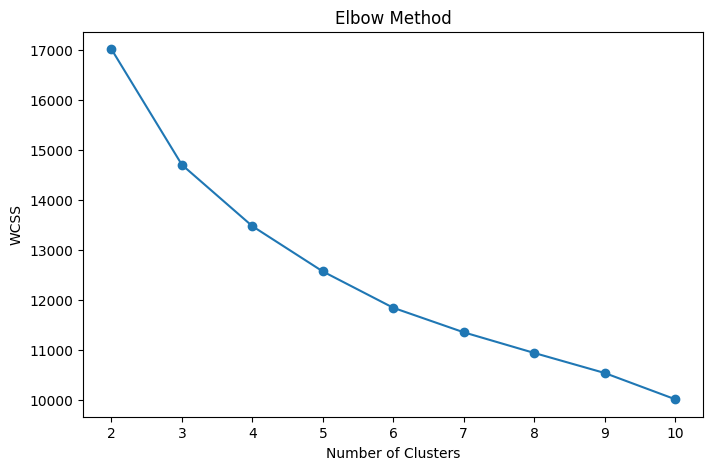

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [13]:
scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    scores.append(score)

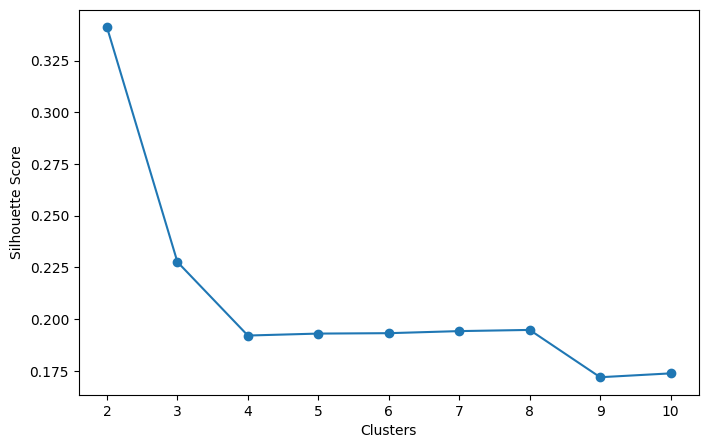

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker="o")

plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")

plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_pca)

In [16]:
pca2 = PCA(n_components=2)

X_2D = pca2.fit_transform(X_scaled)

plot_df = pd.DataFrame(X_2D, columns=["PC1","PC2"])

plot_df["Cluster"] = df["Cluster"]

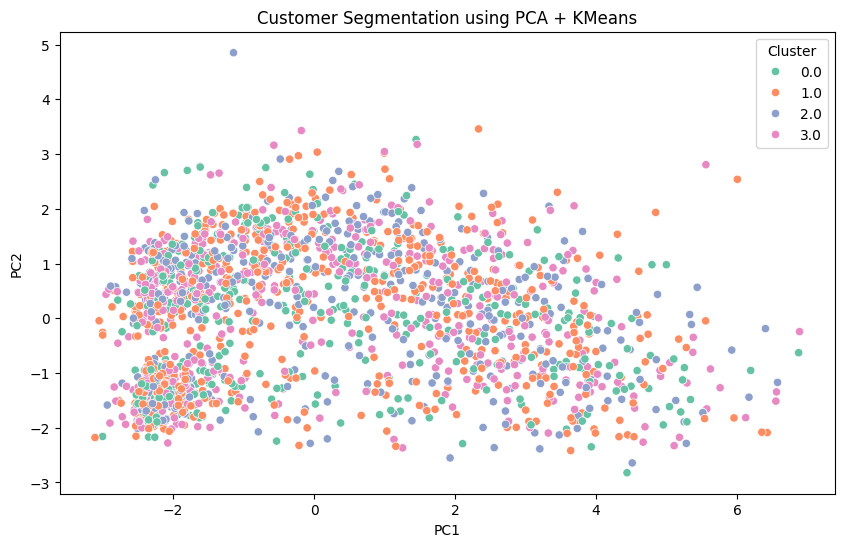

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation using PCA + KMeans")

plt.show()

In [18]:
cluster_summary = df.groupby("Cluster")[[
    "Income",
    "Age",
    "Total_Spending"
]].mean()

cluster_summary

,Income,Age,Total_Spending
Cluster,,,
0,63509.710526,61.082996,919.287449
1,44391.703704,61.586420,183.387346
2,77273.376782,55.431772,1430.340122
3,30358.593482,46.644940,120.101201


In [19]:
df['Cluster'].value_counts()

,count
Cluster,
1,648
3,583
0,494
2,491


In [20]:
cluster_summary

,Income,Age,Total_Spending
Cluster,,,
0,63509.710526,61.082996,919.287449
1,44391.703704,61.586420,183.387346
2,77273.376782,55.431772,1430.340122
3,30358.593482,46.644940,120.101201
